In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
#Configuración de Seaborn
sns.set_theme(style="whitegrid",palette="muted")
#Carga del archivo y exploración
df = pd.read_csv('winequality-red.csv')
print(df.shape)
print(df.info())

(1599, 12)
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


In [3]:
print("Estadísticas:")
print(df.describe().round(2))

Estadísticas:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count        1599.00           1599.00      1599.00         1599.00   
mean            8.32              0.53         0.27            2.54   
std             1.74              0.18         0.19            1.41   
min             4.60              0.12         0.00            0.90   
25%             7.10              0.39         0.09            1.90   
50%             7.90              0.52         0.26            2.20   
75%             9.20              0.64         0.42            2.60   
max            15.90              1.58         1.00           15.50   

       chlorides  free sulfur dioxide  total sulfur dioxide  density       pH  \
count    1599.00              1599.00               1599.00  1599.00  1599.00   
mean        0.09                15.87                 46.47     1.00     3.31   
std         0.05                10.46                 32.90     0.00     0.15   
min         0.01      

In [4]:
#Valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [6]:
#Duplicados
duplicados=df.duplicated().sum()
print(f"Registros duplicados encontrados:{duplicados}")
df.drop_duplicates(inplace=True)
print("Nuevo tamaño del dataset:")
print(df.shape)

Registros duplicados encontrados:240
Nuevo tamaño del dataset:
(1359, 12)


In [7]:
#Outliers
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR=Q3-Q1
outliers=((df<(Q1-1.5*IQR))|(df>(Q3+1.5*IQR))).sum()
print("Cantidad de outliers por columna:")
print(outliers)

Cantidad de outliers por columna:
fixed acidity            41
volatile acidity         19
citric acid               1
residual sugar          126
chlorides                87
free sulfur dioxide      26
total sulfur dioxide     45
density                  35
pH                       28
sulphates                55
alcohol                  12
quality                  27
dtype: int64


In [8]:
#Normalización
scaler=MinMaxScaler()
df_normalizado=pd.DataFrame(scaler.fit_transform(df),columns=df.columns)
print(df_normalizado.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       0.247788          0.397260         0.00        0.068493   0.106845   
1       0.283186          0.520548         0.00        0.116438   0.143573   
2       0.283186          0.438356         0.04        0.095890   0.133556   
3       0.584071          0.109589         0.56        0.068493   0.105175   
4       0.247788          0.369863         0.00        0.061644   0.105175   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0             0.140845              0.098940  0.567548  0.606299   0.137725   
1             0.338028              0.215548  0.494126  0.362205   0.209581   
2             0.197183              0.169611  0.508811  0.409449   0.191617   
3             0.225352              0.190813  0.582232  0.330709   0.149701   
4             0.169014              0.120141  0.567548  0.606299   0.137725   

    alcohol  quality  
0  0.153846      0.4  
1  0.21538

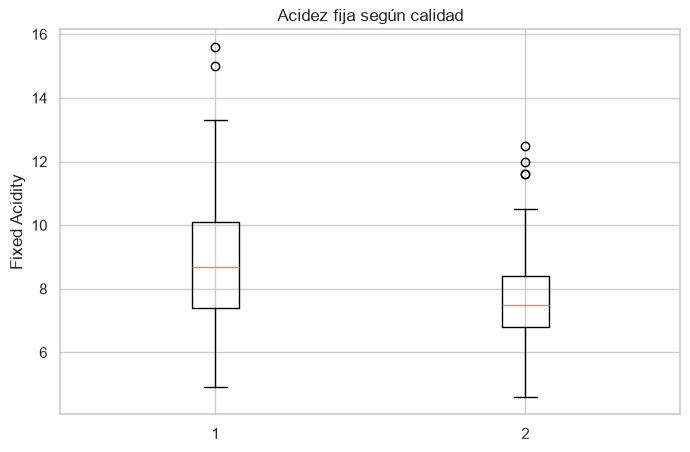

In [10]:
#¿Cuál es la diferencia de acidez fija entre vinos con calidad >=7 y <5?
alta=df[df['quality']>= 7]['fixed acidity']
baja=df[df['quality']<5]['fixed acidity']
plt.figure(figsize=(8,5))
plt.boxplot([alta, baja],label=['Calidad >= 7', 'Calidad < 5'])
plt.title('Acidez fija según calidad')
plt.ylabel('Fixed Acidity')
plt.show()

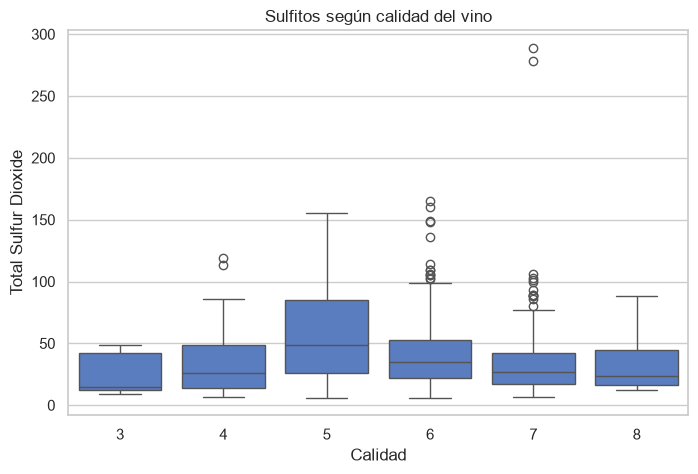

In [11]:
#¿Cómo varía el nivel de sulfitos según la calidad?
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='quality',y='total sulfur dioxide')
plt.title('Sulfitos según calidad del vino')
plt.xlabel('Calidad')
plt.ylabel('Total Sulfur Dioxide')
plt.show()